In [1]:
# Import tools
import json
import platform
import shutil
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from google.colab import files
from IPython.display import display
from scipy.linalg import qr
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics.pairwise import haversine_distances
from sklearn.pipeline import Pipeline


In [2]:
# Set plot style
plt.rc("text",usetex=False)
plt.rc("font",family="serif")
plt.rc("mathtext",fontset="cm")
plt.rc("font",size=13)
plt.rc("axes",labelsize=14)
plt.rc("xtick",labelsize=11)
plt.rc("ytick",labelsize=11)
plt.rc("legend",fontsize=11)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [3]:
# Load frozen archives
def newest(pattern):
    matches = list(Path(".").glob(pattern))
    return max(matches,key=lambda p:p.stat().st_mtime) if matches else None

regionarchive = newest("01-regions*.zip")
validationarchive = newest("05-validation*.zip")
if regionarchive is None or validationarchive is None:
    files.upload()
    regionarchive = newest("01-regions*.zip")
    validationarchive = newest("05-validation*.zip")
if regionarchive is None or validationarchive is None:
    raise FileNotFoundError("Upload 01-regions.zip and 05-validation.zip")

regiondata = Path("regions_data")
validationdata = Path("validation_data")
for path in [regiondata,validationdata]:
    shutil.rmtree(path,ignore_errors=True)
    path.mkdir()
regionrequired = ["sites.csv","target.csv","pm.csv","smoke.csv"]
validationrequired = ["hyperparameters.json","manifest.json","graph_summary.csv","sensor_sets.csv",
                    "protocol_summary.csv","primary_test_results.csv","placement_results.csv","placement_bootstrap.csv"]

def extract_required(archive,destination,names):
    with zipfile.ZipFile(archive) as bundle:
        members = {Path(name).name:name for name in bundle.namelist()}
        missing = [name for name in names if name not in members]
        if missing:
            raise FileNotFoundError("Missing from archive: "+", ".join(missing))
        for name in names:
            with bundle.open(members[name]) as source,open(destination/name,"wb") as output:
                shutil.copyfileobj(source,output)

extract_required(regionarchive,regiondata,regionrequired)
extract_required(validationarchive,validationdata,validationrequired)
print("Region archive:",regionarchive)
print("Validation archive:",validationarchive)


Saving 01-regions.zip to 01-regions.zip
Saving 05-validation.zip to 05-validation.zip
Region archive: 01-regions.zip
Validation archive: 05-validation.zip


In [4]:
# Read frozen data
sites = pd.read_csv(regiondata/"sites.csv",dtype={"site":str})
target = pd.read_csv(regiondata/"target.csv",dtype={"site":str})
pm = pd.read_csv(regiondata/"pm.csv",index_col=0)
smoke = pd.read_csv(regiondata/"smoke.csv",index_col=0)
pm.index = pd.to_datetime(pm.index)
smoke.index = pd.to_datetime(smoke.index)
pm.columns = pm.columns.astype(str)
smoke.columns = smoke.columns.astype(str)
pm = pm.apply(pd.to_numeric,errors="coerce").sort_index()
smoke = smoke.apply(pd.to_numeric,errors="coerce").sort_index()
target["weight"] = pd.to_numeric(target["weight"],errors="coerce")
order = target["site"].tolist()
sites = sites.set_index("site").reindex(order).reset_index()
pm = pm.reindex(columns=order)
smoke = smoke.reindex(index=pm.index,columns=order).fillna(0).astype(int)

with open(validationdata/"hyperparameters.json") as f:
    frozen = json.load(f)
with open(validationdata/"manifest.json") as f:
    frozenmanifest = json.load(f)
archgraph = pd.read_csv(validationdata/"graph_summary.csv")
archivesets = pd.read_csv(validationdata/"sensor_sets.csv",dtype={"site":str})
archiveprotocol = pd.read_csv(validationdata/"protocol_summary.csv")
archivetest = pd.read_csv(validationdata/"primary_test_results.csv")
archivedplacements = pd.read_csv(validationdata/"placement_results.csv")
archivedbootstrap = pd.read_csv(validationdata/"placement_bootstrap.csv")
print("Region stations:",len(order))
print("Frozen K / horizon / beta:",frozen["K"],frozen["horizon"],frozen["beta"])


Region stations: 104
Frozen K / horizon / beta: 30 2.0 0.0001


In [5]:
# Rebuild frozen target samples
weights = target.set_index("site")["weight"].reindex(order).fillna(0)
fullsites = weights[weights>0].index.tolist()
fullweights = weights[fullsites]/weights[fullsites].sum()

def observed_target(matrix,siteweights,threshold):
    block = matrix[siteweights.index]
    coverage = block.notna().mul(siteweights,axis=1).sum(axis=1)
    value = block.mul(siteweights,axis=1).sum(axis=1)/coverage.where(coverage>0)
    return pd.DataFrame({"target":value.where(coverage>=threshold),"coverage":coverage})

full90 = observed_target(pm,fullweights,.90)
smokeshare = smoke.ge(1).mul(fullweights,axis=1).sum(axis=1)
mediumshare = smoke.ge(2).mul(fullweights,axis=1).sum(axis=1)
heavyshare = smoke.ge(3).mul(fullweights,axis=1).sum(axis=1)
available = set(pm.index)
rows = []
for targetdate in pm.index:
    dates = [targetdate-pd.Timedelta(days=d) for d in [4,3,2]]
    if not all(d in available for d in dates) or not all(d.year==targetdate.year for d in dates):
        continue
    block = pm.loc[dates]
    rows.append({"target_date":targetdate,"first_date":dates[0],"middle_date":dates[1],"latest_date":dates[2],
                 "year":targetdate.year,"input_fraction":block.notna().mean().mean(),
                 "complete_stations":int(block.notna().all(axis=0).sum()),"smoke_share":smokeshare.loc[targetdate],
                 "medium_heavy_share":mediumshare.loc[targetdate],"heavy_share":heavyshare.loc[targetdate]})

samples = pd.DataFrame(rows)
samples["split"] = np.select([samples.year.between(2018,2021),samples.year.eq(2022),samples.year.between(2023,2024)],
                           ["train","validation","test"],default = "exclude")
samples["target_full90"] = full90["target"].reindex(samples.target_date).to_numpy()
samples["coverage_full90"] = full90["coverage"].reindex(samples.target_date).to_numpy()
primarydevelopment = samples[samples.year.between(2018,2022)&samples.target_full90.notna()].copy()
primarytest = samples[samples.year.eq(2024)&samples.target_full90.notna()].copy()
print("Target sites:",len(fullsites))
print("Development samples:",len(primarydevelopment))
print("Untouched 2024 samples:",len(primarytest))


Target sites: 21
Development samples: 722
Untouched 2024 samples: 135


In [6]:
# Rebuild frozen training graph
training = pm[pm.index.year<=2021]
yearcounts = training.notna().groupby(training.index.year).sum().T.reindex(columns=[2018,2019,2020,2021],fill_value=0)
trainingyears = yearcounts.gt(0).sum(axis=1)
mediandays = yearcounts.where(yearcounts>0).median(axis=1)
candidateorder = yearcounts.index[trainingyears.ge(3)&mediandays.ge(40)].tolist()
candidatesites = sites.set_index("site").reindex(candidateorder).reset_index()
candidateweights = weights.reindex(candidateorder).fillna(0)
coordinates = np.radians(candidatesites[["lat","lon"]].to_numpy())
distance = 6371.0088*haversine_distances(coordinates)
n = len(candidateorder)
k = 10
neighbors = np.argsort(distance,axis=1)[:,1:k+1]
edgemask = np.zeros((n,n),dtype=bool)
edgemask[np.repeat(np.arange(n),k),neighbors.reshape(-1)] = True
edgemask |= edgemask.T
np.fill_diagonal(edgemask,False)
correlation = training[candidateorder].corr(min_periods=60).fillna(0).to_numpy()
correlation = np.clip(correlation,-1,1)
np.fill_diagonal(correlation,1)
upper = np.triu(edgemask,1)
sigma = np.median(distance[upper])
W = np.where(edgemask,np.exp(-(distance/sigma)**2)*np.maximum(correlation,0)**2,0)
W = (W+W.T)/2
np.fill_diagonal(W,0)
components,_ = connected_components(csr_matrix(W>0),directed=False)
degree = W.sum(axis=1)
L = np.diag(degree)-W
values,vectors = np.linalg.eigh(L)
values = np.maximum(values,0)
print("Candidates:",n)
print("Geographic edges:",int(upper.sum()))
print("Positive weighted edges:",int(np.triu(W>0,1).sum()))
print("Components:",components)
print("Algebraic connectivity:",values[1])


Candidates: 99
Geographic edges: 634
Positive weighted edges: 634
Components: 1
Algebraic connectivity: 0.0008592884040711255


In [7]:
# Define frozen target model
def build_target_model(K,horizon,targetweights):
    scaled = values[:K]/values[K-1]
    basis = vectors[:,:K]
    decay = np.exp(-np.outer(horizon*np.array([0,.25,.5]),scaled))
    modelblocks = basis[:,None,:]*decay[None,:,:]
    targetdirection = np.exp(-horizon*scaled)*(basis.T@targetweights.reindex(candidateorder).fillna(0).to_numpy())
    sensorinfo = np.einsum("vtk,vtl->vkl",modelblocks,modelblocks)
    return modelblocks,sensorinfo,targetdirection

def select_taps(sensorinfo,targetdirection,beta,budget):
    M = beta*np.eye(len(targetdirection))
    selected = []
    available = np.ones(len(sensorinfo),dtype=bool)
    normalizer = targetdirection@targetdirection
    for _ in range(budget):
        best = -1
        bestscore = np.inf
        for station in np.flatnonzero(available):
            score = beta*(targetdirection@np.linalg.solve(M+sensorinfo[station],targetdirection))/normalizer
            if score<bestscore-1e-14:
                best = int(station)
                bestscore = score
        selected.append(best)
        available[best] = False
        M += sensorinfo[best]
    return selected

bestK = int(frozen["K"])
besthorizon = float(frozen["horizon"])
bestbeta = float(frozen["beta"])
referencebudget = int(frozen["sensor_budget"])
measurement_blocks,sensor_info,target_direction = build_target_model(bestK,besthorizon,fullweights)
tapsset = select_taps(sensor_info,target_direction,bestbeta,referencebudget)
tapssites = [candidateorder[i] for i in tapsset]
print("TAPS-10:"," | ".join(tapssites))


TAPS-10: 06-001-0015 | 06-001-0007 | 06-013-0002 | 06-069-0002 | 06-011-0007 | 06-099-0006 | 06-007-0008 | 06-095-0004 | 06-053-0008 | 06-013-1004


In [8]:
# Audit frozen reconstruction
archivegraph = archgraph.set_index("metric")["value"]
archivesites = archivesets[archivesets.method.eq("TAPS")].sort_values("rank").site.tolist()
archiveprimary = archiveprotocol[archiveprotocol.protocol.eq("primary_full90_2024")].iloc[0]
checks = {
    "104 region stations":len(order)==104, "21 target sites":len(fullsites)==21,
    "99 frozen candidates":n==99, "634 geographic edges":int(upper.sum())==634,
    "634 positive weighted edges":int(np.triu(W>0,1).sum())==634,
    "Training graph connected":components==1, "Target weights preserved":np.isclose(candidateweights.sum(),1),
    "Frozen K=30":bestK==30, "Frozen horizon=2":np.isclose(besthorizon,2),
    "Frozen beta=1e-4":np.isclose(bestbeta,1e-4),
    "135 untouched 2024 dates":len(primarytest)==135,
    "Archive protocol agrees":int(archiveprimary.samples)==len(primarytest),
    "Archive candidate count agrees":int(archivegraph["Candidate stations"])==n,
    "Archive edge count agrees":int(archivegraph["Geographic edges"])==upper.sum(),
    "TAPS prefix agrees with sensor_sets.csv":tapssites==archivesites,
    "TAPS prefix agrees with hyperparameters":tapssites==frozen["selected_sites"]
}
audit = pd.DataFrame({"check":checks.keys(),"passed":checks.values()})
display(audit)
if not audit.passed.all():
    raise ValueError("Frozen-state audit failed: "+", ".join(audit.loc[~audit.passed,"check"]))
print("Frozen state reproduced successfully.")


,check,passed
0,104 region stations,True
1,21 target sites,True
2,99 frozen candidates,True
3,634 geographic edges,True
4,634 positive weighted edges,True
5,Training graph connected,True
6,Target weights preserved,True
7,Frozen K=30,True
8,Frozen horizon=2,True
9,Frozen beta=1e-4,True


Frozen state reproduced successfully.


In [9]:
# Define placement methods
maxbudget = 30

def select_raw(modelblocks,sensorinfo,targetdirection,beta,budget):
    M = beta*np.eye(len(targetdirection))
    selected = []
    available = np.ones(len(sensorinfo),dtype=bool)
    normalizer = targetdirection@targetdirection
    for _ in range(budget):
        h = np.linalg.solve(M,targetdirection)
        best = -1
        bestscore = -np.inf
        for i in np.flatnonzero(available):
            q = modelblocks[i]@h
            score = beta*(q@q)/normalizer
            if score>bestscore+1e-14:
                best = int(i)
                bestscore = score
        selected.append(best)
        available[best] = False
        M += sensorinfo[best]
    return selected

def select_geographic(budget):
    selected = [int(np.argmin(distance.max(axis=1)))]
    while len(selected)<budget:
        nearest = distance[:,selected].min(axis=1)
        nearest[selected] = -np.inf
        selected.append(int(np.argmax(nearest)))
    return selected

def select_doptimal(sensorinfo,beta,budget):
    M = beta*np.eye(sensorinfo.shape[1])
    selected = []
    available = np.ones(len(sensorinfo),dtype=bool)
    for _ in range(budget):
        best = -1
        bestscore = -np.inf
        for i in np.flatnonzero(available):
            sign,score = np.linalg.slogdet(M+sensorinfo[i])
            if sign>0 and score>bestscore+1e-12:
                best = int(i)
                bestscore = score
        selected.append(best)
        available[best] = False
        M += sensorinfo[best]
    return selected


In [10]:
# Build thirty-site orders
tapsorder = select_taps(sensor_info,target_direction,bestbeta,maxbudget)
raworder = select_raw(measurement_blocks,sensor_info,target_direction,bestbeta,maxbudget)
targetorder = np.argsort(-candidateweights.to_numpy(),kind="stable")[:maxbudget].tolist()
degreeorder = np.argsort(-degree,kind="stable")[:maxbudget].tolist()
geographicorder = select_geographic(maxbudget)
doptimalorder = select_doptimal(sensor_info,bestbeta,maxbudget)
_,_,pivots = qr(vectors[:,:bestK].T,pivoting=True,mode="economic")
qrorder = [int(i) for i in pivots[:maxbudget]]
placementorders = {"TAPS":tapsorder,"Raw response":raworder,"Target weight":targetorder,"Geographic coverage":geographicorder,
                 "Weighted degree":degreeorder,"D-optimal":doptimalorder,"QR pivoting":qrorder}

rows = []
for method in ["TAPS","Target weight","Geographic coverage","Weighted degree","D-optimal","QR pivoting"]:
    expected = archivesets[archivesets.method.eq(method)].sort_values("rank").site.tolist()
    observed = [candidateorder[i] for i in placementorders[method][:referencebudget]]
    rows.append({"method":method,"exact_order_match":observed==expected,"set_match":set(observed)==set(expected)})
placementaudit = pd.DataFrame(rows)
display(placementaudit)
if not placementaudit[["exact_order_match","set_match"]].to_numpy().all():
    raise ValueError("Archived placement audit failed")
if any(len(v)!=maxbudget or len(set(v))!=maxbudget for v in placementorders.values()):
    raise ValueError("Invalid 30-site order")
print("All archived placements and 30-site orders passed.")


,method,exact_order_match,set_match
0,TAPS,True,True
1,Target weight,True,True
2,Geographic coverage,True,True
3,Weighted degree,True,True
4,D-optimal,True,True
5,QR pivoting,True,True


All archived placements and 30-site orders passed.


In [11]:
# Check model-risk prefixes
def target_risk(selected,info=sensor_info,g=target_direction):
    M = bestbeta*np.eye(bestK)
    for i in selected:
        M += info[i]
    return np.sqrt(bestbeta*(g@np.linalg.solve(M,g))/(g@g))

shownbudgets = [3,5,10,15,20,25,30]
rows = []
for method,orderindices in placementorders.items():
    previous = np.inf
    for budget in shownbudgets:
        risk = target_risk(orderindices[:budget])
        rows.append({"method":method,"budget":budget,"risk":risk,"decreases":risk<=previous+1e-12})
        previous = risk
riskcheck = pd.DataFrame(rows)
display(riskcheck.pivot(index="method",columns="budget",values="risk").round(4))
if not riskcheck.decreases.all():
    raise ValueError("A model-risk curve increased")


budget,3,5,10,15,20,25,30
method,,,,,,,
D-optimal,0.9965,0.9965,0.7228,0.4986,0.0547,0.0508,0.0199
Geographic coverage,0.9441,0.2159,0.0845,0.0826,0.0235,0.0166,0.0153
QR pivoting,1.0000,1.0000,0.9961,0.8019,0.6592,0.4764,0.0205
Raw response,0.1095,0.0583,0.0404,0.0206,0.0163,0.0107,0.0083
TAPS,0.0545,0.0285,0.0138,0.0111,0.0084,0.0070,0.0063
Target weight,0.0618,0.0441,0.0323,0.0288,0.0183,0.0104,0.0095
Weighted degree,0.0798,0.0574,0.0472,0.0336,0.0308,0.0277,0.0255


In [12]:
# Define prediction tools
def fit_calibration(prediction,truth):
    valid = np.isfinite(prediction)&np.isfinite(truth)
    X = np.column_stack([np.ones(valid.sum()),prediction[valid]])
    return np.linalg.lstsq(X,truth[valid],rcond=None)[0]

def prediction_metrics(prediction,truth):
    valid = np.isfinite(prediction)&np.isfinite(truth)
    prediction = np.asarray(prediction,float)[valid]
    truth = np.asarray(truth,float)[valid]
    error = prediction-truth
    scale = np.std(truth,ddof=1)
    corr = np.nan
    if len(truth)>1 and np.std(prediction)>0 and scale>0:
        corr = np.corrcoef(prediction,truth)[0,1]
    rmse = np.sqrt(np.mean(error**2))
    return {"n":len(truth),"mae":np.mean(np.abs(error)),"rmse":rmse,"nrmse":rmse/scale,"bias":np.mean(error),"correlation":corr}

def graph_predictions(modelblocks,g,beta,selected,frame,date_columns=("first_date","middle_date","latest_date")):
    K = modelblocks.shape[2]
    design = modelblocks[selected].reshape(-1,K)
    selectedsites = [candidateorder[i] for i in selected]
    predictions = []
    observedcounts = []
    for row in frame.itertuples():
        dates = [getattr(row,c) for c in date_columns]
        y = pm.loc[dates,selectedsites].to_numpy().T.reshape(-1)
        observed = np.isfinite(y)
        A = design[observed]
        M = beta*np.eye(K)+A.T@A
        state = np.linalg.solve(M,A.T@y[observed])
        predictions.append(g@state)
        observedcounts.append(observed.sum())
    return np.asarray(predictions),np.asarray(observedcounts)


In [13]:
# Define frozen forecasting models
def build_features(frame,selected,date_columns=("first_date","middle_date","latest_date")):
    selectedsites = [candidateorder[i] for i in selected]
    rows = []
    for row in frame.itertuples():
        dates = [getattr(row,c) for c in date_columns]
        block = pm.loc[dates,selectedsites].to_numpy().T.reshape(-1)
        angle = 2*np.pi*row.target_date.dayofyear/365.25
        rows.append(np.r_[block,np.sin(angle),np.cos(angle)])
    return np.asarray(rows,float)

def fit_forest(X,y):
    model = Pipeline([("imputer",SimpleImputer(strategy="median",add_indicator=True)),
                    ("model",RandomForestRegressor(n_estimators=500,max_depth=int(frozen["forest_depth"]),
                     min_samples_leaf = int(frozen["forest_leaf"]),max_features = float(frozen["forest_features"]),
                     random_state = 7,n_jobs = -1))])
    return model.fit(X,y)

def evaluate_placement(selected,modelblocks=measurement_blocks,date_columns=("first_date","middle_date","latest_date")):
    ydev = primarydevelopment.target_full90.to_numpy(float)
    ytest = primarytest.target_full90.to_numpy(float)
    graphdev,_ = graph_predictions(modelblocks,target_direction,bestbeta,selected,primarydevelopment,date_columns)
    graphtest,_ = graph_predictions(modelblocks,target_direction,bestbeta,selected,primarytest,date_columns)
    intercept,slope = fit_calibration(graphdev,ydev)
    graphprediction = intercept+slope*graphtest
    forest = fit_forest(build_features(primarydevelopment,selected,date_columns),ydev)
    forestprediction = forest.predict(build_features(primarytest,selected,date_columns))
    return {"Graph diffusion":graphprediction,"Random forest":forestprediction}


In [14]:
# Verify frozen forecasts
truth10 = primarytest.target_full90.to_numpy(float)
predictions10 = evaluate_placement(placementorders["TAPS"][:10])
rows = []
for predictor,prediction in predictions10.items():
    metrics = prediction_metrics(prediction,truth10)
    archived = archivetest[archivetest.model.eq(predictor)].iloc[0]
    rows.append({"predictor":predictor,"new_mae":metrics["mae"],"archive_mae":archived.mae,
                 "mae_diff":metrics["mae"]-archived.mae,"new_rmse":metrics["rmse"],"archive_rmse":archived.rmse})
tapsforecastaudit = pd.DataFrame(rows)
display(tapsforecastaudit)
if not np.allclose(tapsforecastaudit.new_mae,tapsforecastaudit.archive_mae,atol=5e-6,rtol=0):
    raise ValueError("TAPS-10 MAE audit failed")

rows = []
for method in ["TAPS","Target weight","Geographic coverage","Weighted degree","D-optimal","QR pivoting"]:
    predictions = evaluate_placement(placementorders[method][:10])
    for predictor,prediction in predictions.items():
        metrics = prediction_metrics(prediction,truth10)
        archived = archivedplacements[
            archivedplacements.protocol.eq("full90_2024")
            & archivedplacements.placement.eq(method)
            & archivedplacements.predictor.eq(predictor)
        ].iloc[0]
        rows.append({
            "method":method, "predictor":predictor, "mae":metrics["mae"],
            "archive_mae":archived.mae, "diff":abs(metrics["mae"]-archived.mae)
        })
forecastaudit = pd.DataFrame(rows)
display(forecastaudit.pivot(index="method",columns="predictor",values="mae").round(6))
if forecastaudit["diff"].max()>5e-6:
    raise ValueError("Archived forecast audit failed")
print("All frozen forecast audits passed.")


,predictor,new_mae,archive_mae,mae_diff,new_rmse,archive_rmse
0,Graph diffusion,2.489696,2.489696,0.000000e+00,3.057306,3.057306
1,Random forest,2.187272,2.187272,-4.440892e-16,2.762998,2.762998


predictor,Graph diffusion,Random forest
method,,
D-optimal,3.353718,2.522607
Geographic coverage,2.384035,2.566228
QR pivoting,3.439265,2.866331
TAPS,2.489696,2.187272
Target weight,2.286740,2.388592
Weighted degree,2.666196,2.341699


All frozen forecast audits passed.


In [15]:
# Run held-out sensor-budget experiment
budgetvalues = list(range(3,31))
methodorder = list(placementorders)
resultrows = []
predictionrows = []
truth = primarytest.target_full90.to_numpy(float)
start = time.time()

for number,method in enumerate(methodorder,1):
    t0 = time.time()
    for budget in budgetvalues:
        for predictor,prediction in evaluate_placement(placementorders[method][:budget]).items():
            resultrows.append({"method":method,"budget":budget,"predictor":predictor,**prediction_metrics(prediction,truth)})
            predictionrows.extend(
                {"target_date":date,"method":method,"budget":budget,"predictor":predictor,
                 "truth":y,"prediction":p,"error":p-y}
                for date,y,p in zip(primarytest.target_date,truth,prediction)
            )
    pd.DataFrame(resultrows).to_csv("budget_results.csv",index=False)
    pd.DataFrame(predictionrows).to_csv("budget_predictions.csv",index=False)
    print(f"{number}/7 {method}: {(time.time()-t0)/60:.1f} min | total {(time.time()-start)/60:.1f} min")

budgetresults = pd.DataFrame(resultrows)
budgetpredictions = pd.DataFrame(predictionrows)
print("Rows:",len(budgetresults),"| predictions:",len(budgetpredictions),"| minutes:",round((time.time()-start)/60,1))


1/7 TAPS: 3.3 min | total 3.3 min
2/7 Raw response: 3.2 min | total 6.5 min
3/7 Target weight: 3.3 min | total 9.8 min
4/7 Geographic coverage: 3.1 min | total 12.9 min
5/7 Weighted degree: 3.2 min | total 16.1 min
6/7 D-optimal: 3.1 min | total 19.2 min
7/7 QR pivoting: 3.1 min | total 22.4 min
Rows: 392 | predictions: 52920 | minutes: 22.4


budget,3,5,10,15,20,25,30
method,,,,,,,
TAPS,2.3586,2.3994,2.4897,2.5337,2.4834,2.5348,2.5266
Raw response,2.4501,2.4173,2.6451,2.6330,2.5662,2.5649,2.6133
Target weight,2.9644,2.3636,2.2867,2.3501,2.4031,2.4914,2.4674
Geographic coverage,3.2836,2.5087,2.3840,2.3393,2.3983,2.2804,2.3506
Weighted degree,2.6648,2.6124,2.6662,2.6319,2.5856,2.4691,2.6066
D-optimal,3.4395,3.4395,3.3537,3.4114,2.7343,2.7023,2.6443
QR pivoting,3.4170,3.4405,3.4393,3.4257,3.4971,3.4946,2.7162


budget,3,5,10,15,20,25,30
method,,,,,,,
TAPS,2.3389,2.3363,2.1873,2.1799,2.2516,2.2970,2.3134
Raw response,2.3069,2.4019,2.4480,2.5320,2.4415,2.4479,2.3706
Target weight,2.7288,2.5221,2.3886,2.2736,2.4213,2.3813,2.4023
Geographic coverage,2.7748,2.5213,2.5662,2.6182,2.4900,2.4220,2.3012
Weighted degree,2.3058,2.2541,2.3417,2.2771,2.3656,2.3665,2.3818
D-optimal,3.2822,3.4399,2.5226,2.4279,2.3450,2.4112,2.6558
QR pivoting,3.3490,3.1297,2.8663,2.6426,2.6819,2.5700,2.6944


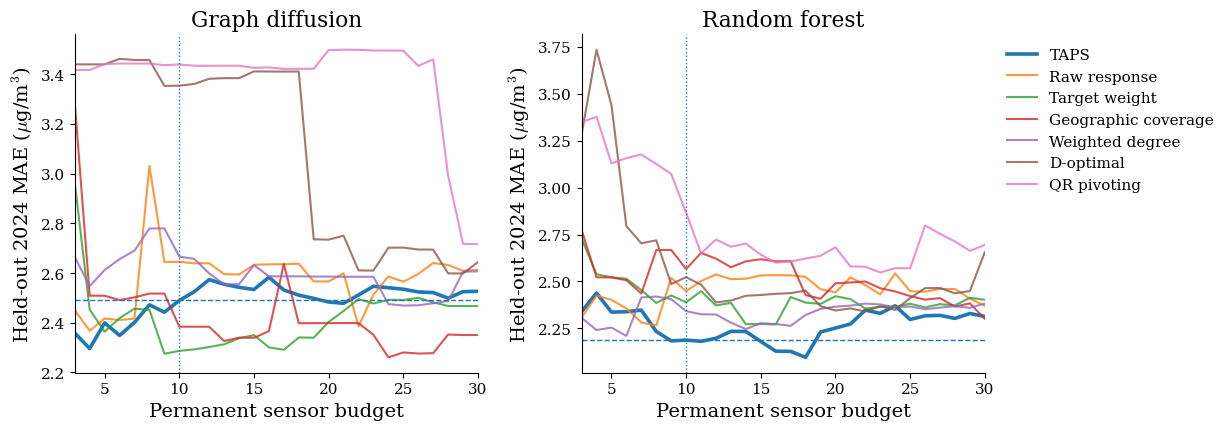

In [16]:
# Summarize held-out budget curves
reference = budgetresults[budgetresults.method.eq("TAPS")&budgetresults.budget.eq(10)].set_index("predictor").mae.to_dict()
rows = []
for predictor,ref in reference.items():
    for method in methodorder:
        curve = budgetresults[
            budgetresults.method.eq(method)&budgetresults.predictor.eq(predictor)
        ].sort_values("budget").reset_index(drop=True)
        crossing = curve.loc[curve.mae<=ref,"budget"]
        sustained = np.nan
        for budget in curve.budget:
            if (curve.loc[curve.budget>=budget,"mae"]<=ref).all():
                sustained = int(budget)
                break
        best = curve.loc[curve.mae.idxmin()]
        rows.append({
            "predictor":predictor, "reference_method":"TAPS", "reference_budget":10,
            "reference_mae":ref, "method":method,
            "first_budget_matching":int(crossing.iloc[0]) if len(crossing) else np.nan,
            "first_sustained_budget":sustained, "best_budget":int(best.budget), "best_mae":best.mae
        })
budgetequivalence = pd.DataFrame(rows)
for predictor in ["Graph diffusion","Random forest"]:
    display(budgetresults[budgetresults.predictor.eq(predictor)&budgetresults.budget.isin(shownbudgets)]
            .pivot(index="method",columns="budget",values="mae").reindex(methodorder).round(4))

fig,axes = plt.subplots(1,2,figsize=(12.5,4.5))
for ax,predictor in zip(axes,["Graph diffusion","Random forest"]):
    for method in methodorder:
        curve = budgetresults[budgetresults.method.eq(method)&budgetresults.predictor.eq(predictor)].sort_values("budget")
        ax.plot(curve.budget,curve.mae,label=method,linewidth=2.6 if method=="TAPS" else 1.5,alpha=1 if method=="TAPS" else .8)
    ax.axvline(10,linestyle=":",linewidth=1)
    ax.axhline(reference[predictor],linestyle="--",linewidth=1)
    ax.set(xlim=(3,30),xlabel="Permanent sensor budget",ylabel=r"Held-out 2024 MAE ($\mu$g/m$^3$)",title=predictor)
axes[1].legend(frameon=False,bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.savefig("heldout_budget_curves.png",dpi=300,bbox_inches="tight")
plt.show()


In [17]:
# Define block bootstrap
def pair_frame(predictor,methoda,budgeta,methodb,budgetb):
    a = budgetpredictions[
        budgetpredictions.predictor.eq(predictor)
        & budgetpredictions.method.eq(methoda)
        & budgetpredictions.budget.eq(budgeta)
    ][["target_date","truth","prediction"]].rename(columns={"prediction":"A"})
    b = budgetpredictions[
        budgetpredictions.predictor.eq(predictor)
        & budgetpredictions.method.eq(methodb)
        & budgetpredictions.budget.eq(budgetb)
    ][["target_date","prediction"]].rename(columns={"prediction":"B"})
    frame = a.merge(b,on="target_date").sort_values("target_date").reset_index(drop=True)
    frame["target_date"] = pd.to_datetime(frame.target_date)
    frame["year"] = frame.target_date.dt.year
    frame["week_label"] = frame.year.astype(str)+"-"+((frame.target_date.dt.dayofyear-1)//7).astype(str)
    return frame

def bootpair(frame,reps=1000,seed=7):
    rng = np.random.default_rng(seed)
    truth = frame.truth.to_numpy(float)
    pa = frame.A.to_numpy(float)
    pb = frame.B.to_numpy(float)
    maediff = np.empty(reps)
    rmsediff = np.empty(reps)
    yearlabels = {y:g.week_label.unique() for y,g in frame.groupby("year")}
    for rep in range(reps):
        chosen = []
        for year,labels in yearlabels.items():
            group = frame[frame.year.eq(year)]
            for label in rng.choice(labels,len(labels),replace=True):
                chosen.extend(group.index[group.week_label.eq(label)].tolist())
        idx = np.asarray(chosen,int)
        ea = pa[idx]-truth[idx]
        eb = pb[idx]-truth[idx]
        maediff[rep] = np.mean(abs(ea))-np.mean(abs(eb))
        rmsediff[rep] = np.sqrt(np.mean(ea**2))-np.sqrt(np.mean(eb**2))
    return {
        "mae_diff":np.mean(abs(pa-truth))-np.mean(abs(pb-truth)),
        "mae_low":np.quantile(maediff,.025), "mae_high":np.quantile(maediff,.975),
        "rmse_diff":np.sqrt(np.mean((pa-truth)**2))-np.sqrt(np.mean((pb-truth)**2)),
        "rmse_low":np.quantile(rmsediff,.025), "rmse_high":np.quantile(rmsediff,.975)
    }


In [18]:
# Verify frozen placement bootstrap
historical = pair_frame("Random forest","TAPS",10,"Target weight",10)
reproduced = bootpair(historical,seed=42)
archivedrow = archivedbootstrap[
    archivedbootstrap.predictor.eq("Random forest")
    & archivedbootstrap.placement_a.eq("TAPS")
    & archivedbootstrap.placement_b.eq("Target weight")
].iloc[0]
quantities = ["mae_diff","mae_low","mae_high","rmse_diff","rmse_low","rmse_high"]
bootaudit = pd.DataFrame({
    "quantity":quantities,
    "reproduced":[reproduced[x] for x in quantities],
    "archived":[archivedrow[x] for x in quantities]
})
bootaudit["diff"] = abs(bootaudit.reproduced-bootaudit.archived)
display(bootaudit)
assert bootaudit["diff"].max()<=1e-10


,quantity,reproduced,archived,diff
0,mae_diff,-0.201320,-0.201320,3.885781e-16
1,mae_low,-0.317207,-0.317207,1.665335e-16
2,mae_high,-0.075455,-0.075455,5.551115e-17
3,rmse_diff,-0.162063,-0.162063,2.775558e-17
4,rmse_low,-0.275448,-0.275448,5.551115e-17
5,rmse_high,-0.040987,-0.040987,6.938894e-18


In [19]:
# Bootstrap oracle budgets
rfpred = budgetpredictions[budgetpredictions.predictor.eq("Random forest")].copy()
rfpred["target_date"] = pd.to_datetime(rfpred.target_date)
wide = rfpred.pivot(index="target_date",columns=["method","budget"],values="prediction").sort_index()
trutharray = rfpred.groupby("target_date").truth.first().reindex(wide.index).to_numpy(float)
tapsarray = wide[("TAPS",10)].to_numpy(float)
week_ids = ((wide.index.dayofyear-1)//7).astype(int)
groups = {w:np.flatnonzero(week_ids==w) for w in pd.unique(week_ids)}
weekkeys = np.array(list(groups))
baselines = [m for m in methodorder if m!="TAPS"]
reps = 1000
rng = np.random.default_rng(107)
rows = []
replicaterows = []
for method in baselines:
    methodbudgets = [b for b in budgetvalues if (method,b) in wide.columns]
    matrix = np.column_stack([wide[(method,b)].to_numpy(float) for b in methodbudgets])
    observed = np.mean(abs(matrix-trutharray[:,None]),axis=0)
    observedbest = int(np.argmin(observed))
    observedtaps = np.mean(abs(tapsarray-trutharray))
    diffs = np.empty(reps)
    chosen = np.empty(reps,int)
    for rep in range(reps):
        idx = np.concatenate([groups[w] for w in rng.choice(weekkeys,len(weekkeys),replace=True)])
        tapsmae = np.mean(abs(tapsarray[idx]-trutharray[idx]))
        baselinemae = np.mean(abs(matrix[idx]-trutharray[idx,None]),axis=0)
        best = int(np.argmin(baselinemae))
        diffs[rep] = tapsmae-baselinemae[best]
        chosen[rep] = methodbudgets[best]
    rows.append({
        "baseline":method, "observed_best_budget":methodbudgets[observedbest],
        "observed_best_mae":observed[observedbest], "taps10_mae":observedtaps,
        "observed_diff":observedtaps-observed[observedbest],
        "bootstrap_low":np.quantile(diffs,.025), "bootstrap_high":np.quantile(diffs,.975),
        "taps_lower_fraction":np.mean(diffs<0), "median_oracle_budget":np.median(chosen)
    })
    replicaterows.extend(
        {"replicate":rep,"baseline":method,"oracle_budget":b,"mae_diff":d}
        for rep,(d,b) in enumerate(zip(diffs,chosen))
    )
oraclebootstrap = pd.DataFrame(rows)
oraclebootstrapreplicates = pd.DataFrame(replicaterows)
display(oraclebootstrap.round(6))


,baseline,observed_best_budget,observed_best_mae,taps10_mae,observed_diff,bootstrap_low,bootstrap_high,taps_lower_fraction,median_oracle_budget
0,Raw response,8,2.265288,2.187272,-0.078015,-0.181481,0.113801,0.697,8.0
1,Target weight,16,2.270136,2.187272,-0.082864,-0.171660,0.050551,0.877,16.0
2,Geographic coverage,30,2.301161,2.187272,-0.113889,-0.282054,0.065657,0.881,30.0
3,Weighted degree,6,2.209748,2.187272,-0.022476,-0.128315,0.136271,0.547,6.0
4,D-optimal,22,2.340032,2.187272,-0.152760,-0.358080,0.082693,0.909,22.0
5,QR pivoting,23,2.547568,2.187272,-0.360295,-0.592448,-0.086210,0.995,23.0


In [20]:
# Stress test all alternatives
labels = [(m,b) for m in baselines for b in budgetvalues]
allmatrix = np.column_stack([wide[label].to_numpy(float) for label in labels])
observedmae = np.mean(abs(allmatrix-trutharray[:,None]),axis=0)
observedbest = int(np.argmin(observedmae))
observedtaps = np.mean(abs(tapsarray-trutharray))
rng = np.random.default_rng(207)
diffs = np.empty(reps)
winners = []
for rep in range(reps):
    idx = np.concatenate([groups[w] for w in rng.choice(weekkeys,len(weekkeys),replace=True)])
    tapsmae = np.mean(abs(tapsarray[idx]-trutharray[idx]))
    competitor = np.mean(abs(allmatrix[idx]-trutharray[idx,None]),axis=0)
    best = int(np.argmin(competitor))
    diffs[rep] = tapsmae-competitor[best]
    winners.append(labels[best])
overall = pd.DataFrame([{
    "taps10_mae":observedtaps, "observed_oracle_method":labels[observedbest][0],
    "observed_oracle_budget":labels[observedbest][1],
    "observed_oracle_mae":observedmae[observedbest],
    "observed_diff":observedtaps-observedmae[observedbest],
    "bootstrap_low":np.quantile(diffs,.025), "bootstrap_high":np.quantile(diffs,.975),
    "taps_lower_fraction":np.mean(diffs<0)
}])
budgetbootstrap = pd.concat(
    [oraclebootstrap.assign(scope="within method"),
     overall.rename(columns={"observed_oracle_method":"baseline"}).assign(scope="all methods")],
    ignore_index=True,sort=False
)
display(overall.round(6))
print(pd.Series(winners).value_counts().head(10))

rows = []
ref = reference["Random forest"]
for method in methodorder:
    part = budgetresults[budgetresults.predictor.eq("Random forest")&budgetresults.method.eq(method)].sort_values("budget")
    best = part.loc[part.mae.idxmin()]
    matching = part[part.mae<=ref]
    rows.append({
        "method":method, "taps10_reference_mae":ref,
        "best_test_budget":int(best.budget), "best_test_mae":best.mae,
        "matched_taps10":len(matching)>0,
        "first_matching_budget":int(matching.iloc[0].budget) if len(matching) else np.nan
    })
budgetsummary = pd.DataFrame(rows)
display(budgetsummary.round(6))


,taps10_mae,observed_oracle_method,observed_oracle_budget,observed_oracle_mae,observed_diff,bootstrap_low,bootstrap_high,taps_lower_fraction
0,2.187272,Weighted degree,6,2.209748,-0.022476,-0.109103,0.164291,0.423


(Weighted degree, 6)         409
(Raw response, 8)            130
(Weighted degree, 4)          91
(Weighted degree, 14)         78
(Geographic coverage, 30)     66
(Raw response, 7)             59
(Raw response, 3)             33
(Target weight, 22)           20
(Target weight, 16)           18
(D-optimal, 22)               13
Name: count, dtype: int64


,method,taps10_reference_mae,best_test_budget,best_test_mae,matched_taps10,first_matching_budget
0,TAPS,2.187272,18,2.095371,True,9.0
1,Raw response,2.187272,8,2.265288,False,NaN
2,Target weight,2.187272,16,2.270136,False,NaN
3,Geographic coverage,2.187272,30,2.301161,False,NaN
4,Weighted degree,2.187272,6,2.209748,False,NaN
5,D-optimal,2.187272,22,2.340032,False,NaN
6,QR pivoting,2.187272,23,2.547568,False,NaN


In [21]:
# Build repeated-observation TAPS designs
reading_schedules = {
    1:{"block_indices":[2],"date_columns":["latest_date"],"label":"1 reading: d-2"},
    2:{"block_indices":[1,2],"date_columns":["middle_date","latest_date"],"label":"2 readings: d-3, d-2"},
    3:{"block_indices":[0,1,2],"date_columns":["first_date","middle_date","latest_date"],
       "label":"3 readings: d-4, d-3, d-2"}
}

reading_blocks = {}
reading_info = {}
reading_orders = {}

for readings,schedule in reading_schedules.items():
    reading_blocks[readings] = measurement_blocks[:,schedule["block_indices"],:]
    reading_info[readings] = np.einsum("vtk,vtl->vkl",reading_blocks[readings],reading_blocks[readings])
    reading_orders[readings] = select_taps(reading_info[readings],target_direction,bestbeta,maxbudget)
    print(readings,"reading(s):"," | ".join(candidateorder[i] for i in reading_orders[readings][:10]))

if reading_orders[3]!=placementorders["TAPS"]:
    raise ValueError("Three-reading TAPS order failed to reproduce")


1 reading(s): 06-001-0015 | 06-053-0008 | 06-101-0003 | 06-001-0007 | 06-097-0004 | 06-085-0006 | 06-077-2010 | 06-085-0005 | 06-079-8002 | 06-081-1001
2 reading(s): 06-001-0015 | 06-085-0006 | 06-009-0001 | 06-097-0004 | 06-069-0002 | 06-077-2010 | 06-095-0004 | 06-063-1010 | 06-013-0002 | 06-053-1003
3 reading(s): 06-001-0015 | 06-001-0007 | 06-013-0002 | 06-069-0002 | 06-011-0007 | 06-099-0006 | 06-007-0008 | 06-095-0004 | 06-053-0008 | 06-013-1004


In [22]:
# Define reading forecasts
def evaluate_reading_design(readings,selected):
    dates = tuple(reading_schedules[readings]["date_columns"])
    modelblocks = reading_blocks[readings]
    ydev = primarydevelopment.target_full90.to_numpy(float)
    ytest = primarytest.target_full90.to_numpy(float)
    graphdev,_ = graph_predictions(modelblocks,target_direction,bestbeta,selected,primarydevelopment,dates)
    graphtest,_ = graph_predictions(modelblocks,target_direction,bestbeta,selected,primarytest,dates)
    intercept,slope = fit_calibration(graphdev,ydev)
    graphprediction = intercept+slope*graphtest
    forest = fit_forest(build_features(primarydevelopment,selected,dates),ydev)
    forestprediction = forest.predict(build_features(primarytest,selected,dates))
    return {"Graph diffusion":graphprediction,"Random forest":forestprediction}

auditpred = evaluate_reading_design(3,reading_orders[3][:10])
rows = []
for predictor in ["Graph diffusion","Random forest"]:
    new = prediction_metrics(auditpred[predictor],truth10)
    old = prediction_metrics(predictions10[predictor],truth10)
    rows.append({"predictor":predictor,"new_mae":new["mae"],"old_mae":old["mae"],"difference":new["mae"]-old["mae"]})
readingaudit = pd.DataFrame(rows)
display(readingaudit)
if not np.allclose(readingaudit.difference,0,atol=1e-10):
    raise ValueError("Three-reading forecast audit failed")


,predictor,new_mae,old_mae,difference
0,Graph diffusion,2.489696,2.489696,0.000000e+00
1,Random forest,2.187272,2.187272,-4.440892e-16


In [23]:
# Run held-out reading tradeoff
readingresultrows = []
readingpredictionrows = []
truth = primarytest.target_full90.to_numpy(float)
start = time.time()

for readings in [1,2,3]:
    t0 = time.time()
    for budget in budgetvalues:
        selected = reading_orders[readings][:budget]
        for predictor,prediction in evaluate_reading_design(readings,selected).items():
            readingresultrows.append({
                "readings_per_sensor":readings, "schedule":reading_schedules[readings]["label"],
                "budget":budget, "predictor":predictor, **prediction_metrics(prediction,truth)
            })
            readingpredictionrows.extend(
                {"target_date":date,"readings_per_sensor":readings,"budget":budget,
                 "predictor":predictor,"truth":y,"prediction":p,"error":p-y}
                for date,y,p in zip(primarytest.target_date,truth,prediction)
            )
    pd.DataFrame(readingresultrows).to_csv("reading_budget_results.csv",index=False)
    pd.DataFrame(readingpredictionrows).to_csv("reading_budget_predictions.csv",index=False)
    print(f"{readings} reading(s): {(time.time()-t0)/60:.1f} min | total {(time.time()-start)/60:.1f} min")

readingresults = pd.DataFrame(readingresultrows)
readingpredictions = pd.DataFrame(readingpredictionrows)
print("Rows:",len(readingresults),"| predictions:",len(readingpredictions))


1 reading(s): 2.0 min | total 2.0 min
2 reading(s): 2.6 min | total 4.6 min
3 reading(s): 3.3 min | total 7.9 min
Rows: 168 | predictions: 22680


,predictor,readings_per_sensor,reference_3read_10sensor_mae,mae_at_10_sensors,first_budget_matching_reference,best_observed_budget,best_observed_mae
0,Graph diffusion,1,2.489696,2.209073,3.0,7,2.195035
1,Graph diffusion,2,2.489696,2.269591,3.0,4,2.206922
2,Graph diffusion,3,2.489696,2.489696,3.0,4,2.296239
3,Random forest,1,2.187272,2.290824,NaN,8,2.265834
4,Random forest,2,2.187272,2.377942,4.0,4,2.166700
5,Random forest,3,2.187272,2.187272,9.0,18,2.095371


budget,3,5,10,15,20,25,30
readings_per_sensor,,,,,,,
1,2.2668,2.3406,2.2091,2.2657,2.2775,2.2977,2.2716
2,2.2310,2.2458,2.2696,2.3172,2.3813,2.4121,2.4310
3,2.3586,2.3994,2.4897,2.5337,2.4834,2.5348,2.5266


budget,3,5,10,15,20,25,30
readings_per_sensor,,,,,,,
1,2.3429,2.3901,2.2908,2.3353,2.3676,2.3657,2.3490
2,2.2722,2.4492,2.3779,2.3828,2.3495,2.3140,2.3045
3,2.3389,2.3363,2.1873,2.1799,2.2516,2.2970,2.3134


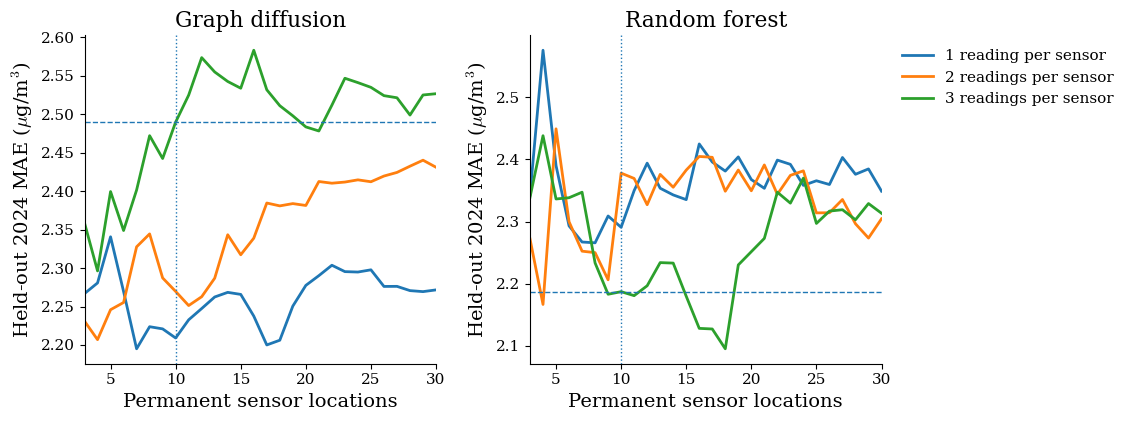

First-budget matches are descriptive on the 2024 test set, not tuned sensor requirements.


In [24]:
# Summarize reading tradeoff
references = {
    predictor:readingresults[
        readingresults.readings_per_sensor.eq(3)
        & readingresults.budget.eq(10)
        & readingresults.predictor.eq(predictor)
    ].mae.iloc[0]
    for predictor in ["Graph diffusion","Random forest"]
}
rows = []
for predictor in references:
    for readings in [1,2,3]:
        curve = readingresults[
            readingresults.predictor.eq(predictor)&readingresults.readings_per_sensor.eq(readings)
        ].sort_values("budget")
        crossing = curve[curve.mae<=references[predictor]]
        best = curve.loc[curve.mae.idxmin()]
        budget10 = curve[curve.budget.eq(10)].iloc[0]
        rows.append({
            "predictor":predictor, "readings_per_sensor":readings,
            "reference_3read_10sensor_mae":references[predictor],
            "mae_at_10_sensors":budget10.mae,
            "first_budget_matching_reference":int(crossing.iloc[0].budget) if len(crossing) else np.nan,
            "best_observed_budget":int(best.budget), "best_observed_mae":best.mae
        })
readingtradeoff = pd.DataFrame(rows)
display(readingtradeoff.round(6))
for predictor in references:
    display(readingresults[readingresults.predictor.eq(predictor)&readingresults.budget.isin(shownbudgets)]
            .pivot(index="readings_per_sensor",columns="budget",values="mae").round(4))

fig,axes = plt.subplots(1,2,figsize=(11.5,4.4))
for ax,predictor in zip(axes,["Graph diffusion","Random forest"]):
    for readings in [1,2,3]:
        curve = readingresults[
            readingresults.predictor.eq(predictor)&readingresults.readings_per_sensor.eq(readings)
        ].sort_values("budget")
        ax.plot(curve.budget,curve.mae,linewidth=2,label=f"{readings} reading"+("" if readings==1 else "s")+" per sensor")
    ax.axvline(10,linestyle=":",linewidth=1)
    ax.axhline(references[predictor],linestyle="--",linewidth=1)
    ax.set(xlim=(3,30),xlabel="Permanent sensor locations",ylabel=r"Held-out 2024 MAE ($\mu$g/m$^3$)",title=predictor)
axes[1].legend(frameon=False,bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.savefig("reading_tradeoff.png",dpi=300,bbox_inches="tight")
plt.show()
print("First-budget matches are descriptive on the 2024 test set, not tuned sensor requirements.")


In [25]:
# Compare equal measurement budgets
common_totals = [12,18,24,30]

def mean_observed_inputs(readings,budget):
    selected = reading_orders[readings][:budget]
    siteset = [candidateorder[i] for i in selected]
    columns = reading_schedules[readings]["date_columns"]
    counts = []
    for row in primarytest.itertuples():
        dates = [getattr(row,c) for c in columns]
        counts.append(np.isfinite(pm.loc[dates,siteset].to_numpy().T.reshape(-1)).sum())
    return np.mean(counts)

rows = []
for predictor in ["Graph diffusion","Random forest"]:
    for total in common_totals:
        for readings in [1,2,3]:
            if total%readings:
                continue
            budget = total//readings
            if not 3<=budget<=30:
                continue
            result = readingresults[
                readingresults.predictor.eq(predictor)
                & readingresults.readings_per_sensor.eq(readings)
                & readingresults.budget.eq(budget)
            ].iloc[0]
            rows.append({
                "predictor":predictor, "nominal_measurements":total,
                "readings_per_sensor":readings, "physical_locations":budget,
                "mae":result.mae, "rmse":result.rmse,
                "mean_observed_inputs":mean_observed_inputs(readings,budget)
            })
equalmeasurement = pd.DataFrame(rows)

for predictor in ["Graph diffusion","Random forest"]:
    display(
        equalmeasurement[equalmeasurement.predictor.eq(predictor)]
        .pivot(index="nominal_measurements",columns="readings_per_sensor",values="mae")
        .rename(columns={1:"1 reading/site",2:"2 readings/site",3:"3 readings/site"})
        .round(4)
    )
display(equalmeasurement[equalmeasurement.nominal_measurements.eq(30)].round(6))


readings_per_sensor,1 reading/site,2 readings/site,3 readings/site
nominal_measurements,,,
12,2.2474,2.2552,2.2962
18,2.2062,2.2871,2.3488
24,2.2948,2.2627,2.4720
30,2.2716,2.3172,2.4897


readings_per_sensor,1 reading/site,2 readings/site,3 readings/site
nominal_measurements,,,
12,2.3940,2.2998,2.4381
18,2.3812,2.2064,2.3384
24,2.3582,2.3271,2.2335
30,2.3490,2.3828,2.1873


,predictor,nominal_measurements,readings_per_sensor,physical_locations,mae,rmse,mean_observed_inputs
9,Graph diffusion,30,1,30,2.271592,2.830274,28.659259
10,Graph diffusion,30,2,15,2.317234,2.857289,29.703704
11,Graph diffusion,30,3,10,2.489696,3.057306,26.866667
21,Random forest,30,1,30,2.348951,2.983298,28.659259
22,Random forest,30,2,15,2.382821,2.869702,29.703704
23,Random forest,30,3,10,2.187272,2.762998,26.866667


In [26]:
# Bootstrap equal measurement budgets
def reading_pair_frame(predictor,ra,ba,rb,bb):
    a = readingpredictions[
        readingpredictions.predictor.eq(predictor)
        & readingpredictions.readings_per_sensor.eq(ra)
        & readingpredictions.budget.eq(ba)
    ][["target_date","truth","prediction"]].rename(columns={"prediction":"A"})
    b = readingpredictions[
        readingpredictions.predictor.eq(predictor)
        & readingpredictions.readings_per_sensor.eq(rb)
        & readingpredictions.budget.eq(bb)
    ][["target_date","prediction"]].rename(columns={"prediction":"B"})
    frame = a.merge(b,on="target_date").sort_values("target_date").reset_index(drop=True)
    frame["target_date"] = pd.to_datetime(frame.target_date)
    frame["year"] = frame.target_date.dt.year
    frame["week_label"] = frame.year.astype(str)+"-"+((frame.target_date.dt.dayofyear-1)//7).astype(str)
    return frame

rows = []
seed = 300

for predictor in ["Graph diffusion","Random forest"]:
    for total in common_totals:
        for other in [1,2]:
            b3 = total//3
            bo = total//other
            frame = reading_pair_frame(predictor,3,b3,other,bo)
            result = bootpair(frame,reps=1000,seed=seed)
            seed += 1
            rows.append({"predictor":predictor,"nominal_measurements":total,"placement_a":f"{b3} sites x 3 readings",
                         "placement_b":f"{bo} sites x {other} reading"+("" if other==1 else "s"),**result})
equalmeasurementbootstrap = pd.DataFrame(rows)

equalmeasurementbootstrap["mae_result"] = np.select([equalmeasurementbootstrap.mae_high<0,equalmeasurementbootstrap.mae_low>0],
                                                   ["3-reading design lower","wider design lower"],default = "Unresolved")
display(
    equalmeasurementbootstrap[
        ["predictor","nominal_measurements","placement_a","placement_b",
         "mae_diff","mae_low","mae_high","mae_result"]
    ].round(6)
)


,predictor,nominal_measurements,placement_a,placement_b,mae_diff,mae_low,mae_high,mae_result
0,Graph diffusion,12,4 sites x 3 readings,12 sites x 1 reading,0.048871,-0.109879,0.207601,Unresolved
1,Graph diffusion,12,4 sites x 3 readings,6 sites x 2 readings,0.041033,-0.066246,0.155262,Unresolved
2,Graph diffusion,18,6 sites x 3 readings,18 sites x 1 reading,0.142597,-0.015634,0.298135,Unresolved
3,Graph diffusion,18,6 sites x 3 readings,9 sites x 2 readings,0.061640,-0.060524,0.186087,Unresolved
4,Graph diffusion,24,8 sites x 3 readings,24 sites x 1 reading,0.177233,0.014941,0.335951,wider design lower
5,Graph diffusion,24,8 sites x 3 readings,12 sites x 2 readings,0.209321,0.067651,0.343267,wider design lower
6,Graph diffusion,30,10 sites x 3 readings,30 sites x 1 reading,0.218104,0.065662,0.373472,wider design lower
7,Graph diffusion,30,10 sites x 3 readings,15 sites x 2 readings,0.172462,0.038579,0.300582,wider design lower
8,Random forest,12,4 sites x 3 readings,12 sites x 1 reading,0.044150,-0.133573,0.192804,Unresolved
9,Random forest,12,4 sites x 3 readings,6 sites x 2 readings,0.138345,0.032336,0.249284,wider design lower


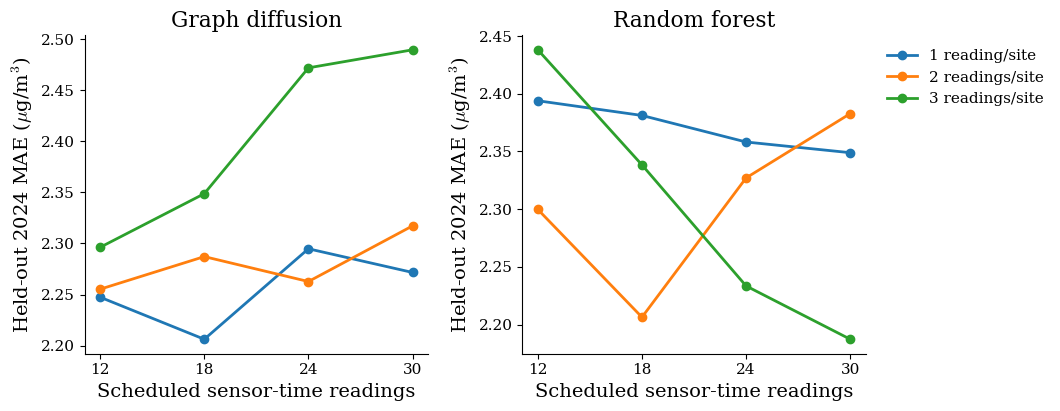

In [27]:
# Plot equal measurement tradeoff
fig,axes = plt.subplots(1,2,figsize=(10.8,4.3))
for ax,predictor in zip(axes,["Graph diffusion","Random forest"]):
    part = equalmeasurement[equalmeasurement.predictor.eq(predictor)]
    for readings in [1,2,3]:
        curve = part[part.readings_per_sensor.eq(readings)].sort_values("nominal_measurements")
        ax.plot(
            curve.nominal_measurements,curve.mae,marker="o",linewidth=2,
            label=f"{readings} reading"+("" if readings==1 else "s")+"/site"
        )
    ax.set(xlabel="Scheduled sensor-time readings",ylabel=r"Held-out 2024 MAE ($\mu$g/m$^3$)",title=predictor)
    ax.set_xticks(common_totals)
axes[1].legend(frameon=False,bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.savefig("equal_measurement_tradeoff.png",dpi=300,bbox_inches="tight")
plt.show()


In [28]:
# Bootstrap 30-reading designs
def threeway_bootstrap(predictor,reps=5000,seed=400):
    part = readingpredictions[readingpredictions.predictor.eq(predictor)].copy()
    part["target_date"] = pd.to_datetime(part.target_date)
    wide = part.pivot(index="target_date",columns=["readings_per_sensor","budget"],values="prediction").sort_index()
    truth = part.groupby("target_date").truth.first().reindex(wide.index).to_numpy(float)
    designs = {"30 sites x 1 reading":(1,30),"15 sites x 2 readings":(2,15),"10 sites x 3 readings":(3,10)}
    preds = {name:wide[key].to_numpy(float) for name,key in designs.items()}
    observed = {name:np.mean(abs(pred-truth)) for name,pred in preds.items()}
    week_ids = ((wide.index.dayofyear-1)//7).astype(int)
    groups = {w:np.flatnonzero(week_ids==w) for w in pd.unique(week_ids)}
    keys = np.array(list(groups))
    rng = np.random.default_rng(seed)
    winners = {name:0 for name in designs}
    d31 = np.empty(reps)
    d32 = np.empty(reps)

    for rep in range(reps):
        idx = np.concatenate([groups[w] for w in rng.choice(keys,len(keys),replace=True)])
        maes = {name:np.mean(abs(pred[idx]-truth[idx])) for name,pred in preds.items()}
        winners[min(maes,key=maes.get)] += 1
        d31[rep] = maes["10 sites x 3 readings"]-maes["30 sites x 1 reading"]
        d32[rep] = maes["10 sites x 3 readings"]-maes["15 sites x 2 readings"]
    winnerrows = [
        {"predictor":predictor,"design":name,"observed_mae":observed[name],
         "bootstrap_best_fraction":winners[name]/reps}
        for name in designs
    ]
    comparisons = []
    for label,diffs,other in [("10x3 minus 30x1",d31,"30 sites x 1 reading"),("10x3 minus 15x2",d32,"15 sites x 2 readings")]:
        comparisons.append({
            "predictor":predictor, "comparison":label,
            "observed_difference":observed["10 sites x 3 readings"]-observed[other],
            "low_95":np.quantile(diffs,.025), "high_95":np.quantile(diffs,.975),
            "low_adjusted":np.quantile(diffs,.0125), "high_adjusted":np.quantile(diffs,.9875),
            "fraction_10x3_lower":np.mean(diffs<0)
        })
    return winnerrows,comparisons


In [29]:
# Run 30-reading bootstrap
winnerrows = []
comparisonrows = []

for i,predictor in enumerate(["Graph diffusion","Random forest"]):
    winners,comparisons = threeway_bootstrap(predictor,5000,400+i)
    winnerrows += winners
    comparisonrows += comparisons

threewaywinners = pd.DataFrame(winnerrows)
threewaycomparisons = pd.DataFrame(comparisonrows)
display(threewaywinners.round(6))
display(threewaycomparisons.round(6))


,predictor,design,observed_mae,bootstrap_best_fraction
0,Graph diffusion,30 sites x 1 reading,2.271592,0.8924
1,Graph diffusion,15 sites x 2 readings,2.317234,0.1064
2,Graph diffusion,10 sites x 3 readings,2.489696,0.0012
3,Random forest,30 sites x 1 reading,2.348951,0.0260
4,Random forest,15 sites x 2 readings,2.382821,0.0092
5,Random forest,10 sites x 3 readings,2.187272,0.9648


,predictor,comparison,observed_difference,low_95,high_95,low_adjusted,high_adjusted,fraction_10x3_lower
0,Graph diffusion,10x3 minus 30x1,0.218104,0.064423,0.388438,0.044031,0.40873,0.0018
1,Graph diffusion,10x3 minus 15x2,0.172462,0.044603,0.306330,0.028336,0.33063,0.0034
2,Random forest,10x3 minus 30x1,-0.161678,-0.315492,0.003045,-0.337541,0.02920,0.9730
3,Random forest,10x3 minus 15x2,-0.195549,-0.372868,-0.023870,-0.392955,-0.00295,0.9888


In [30]:
# Compare equal-budget model information
def model_summary(readings,selected):
    M = bestbeta*np.eye(bestK)
    for i in selected:
        M += reading_info[readings][i]
    risk = np.sqrt(bestbeta*(target_direction@np.linalg.solve(M,target_direction))/(target_direction@target_direction))
    design = reading_blocks[readings][selected].reshape(-1,bestK)
    singular = np.linalg.svd(design,compute_uv=False)
    tol = max(design.shape)*np.finfo(float).eps*singular[0]
    rank = int(np.sum(singular>tol))
    _,_,vt = np.linalg.svd(design,full_matrices=False)
    rowbasis = vt[:rank].T
    projection = rowbasis@(rowbasis.T@target_direction)
    span_error = np.linalg.norm(target_direction-projection)/np.linalg.norm(target_direction)
    return risk,rank,span_error

rows = []
for readings,budget in [(1,30),(2,15),(3,10)]:
    risk,rank,span = model_summary(readings,reading_orders[readings][:budget])
    rows.append({"readings_per_sensor":readings,"physical_locations":budget,"nominal_measurements":readings*budget,
                 "model_risk":risk,"rank":rank,"span_error":span})

equalmodelrisk = pd.DataFrame(rows)
display(equalmodelrisk.round(10))


,readings_per_sensor,physical_locations,nominal_measurements,model_risk,rank,span_error
0,1,30,30,0.011374,29,5.000000e-10
1,2,15,30,0.012134,29,8.000000e-10
2,3,10,30,0.013779,30,0.000000e+00


In [31]:
# Save final tables
budgetresults.to_csv("budget_results.csv",index=False)
budgetpredictions.to_csv("budget_predictions.csv",index=False)
budgetequivalence.to_csv("budget_equivalence.csv",index=False)
budgetsummary.to_csv("budget_summary.csv",index=False)
budgetbootstrap.to_csv("budget_bootstrap.csv",index=False)
oraclebootstrapreplicates.to_csv("budget_bootstrap_replicates.csv",index=False)

readingresults.to_csv("reading_budget_results.csv",index=False)
readingpredictions.to_csv("reading_budget_predictions.csv",index=False)
readingtradeoff.to_csv("reading_tradeoff.csv",index=False)
equalmeasurement.to_csv("equal_measurement_results.csv",index=False)
equalmeasurementbootstrap.to_csv("equal_measurement_bootstrap.csv",index=False)
threewaywinners.to_csv("reading_threeway_winners.csv",index=False)
threewaycomparisons.to_csv("reading_threeway_comparisons.csv",index=False)
equalmodelrisk.to_csv("equal_measurement_model_risk.csv",index=False)


In [32]:
# Build budget manifest
competitors = budgetsummary[~budgetsummary.method.eq("TAPS")]
bestalt = competitors.loc[competitors.best_test_mae.idxmin()]
manifest_budget = {
    "notebook":"09-budgets.ipynb",
    "inputs":["01-regions.zip","05-validation.zip"],
    "candidate_stations":n, "test_year":2024, "test_samples":len(primarytest),
    "budgets":[3,30], "methods":methodorder,
    "predictors":["Graph diffusion","Random forest"],
    "reference":{
        "method":"TAPS", "budget":10,
        "random_forest_mae":reference["Random forest"],
        "graph_diffusion_mae":reference["Graph diffusion"]
    },
    "random_forest_result":{
        "alternative_methods_matching_taps10":int(competitors.matched_taps10.sum()),
        "best_observed_alternative_method":bestalt["method"],
        "best_observed_alternative_budget":int(bestalt["best_test_budget"]),
        "best_observed_alternative_mae":float(bestalt["best_test_mae"]),
        "all_method_oracle_bootstrap_low":float(overall.iloc[0]["bootstrap_low"]),
        "all_method_oracle_bootstrap_high":float(overall.iloc[0]["bootstrap_high"])
    },
    "bootstrap":{
        "replicates":1000, "block":"seven-day calendar blocks",
        "interpretation":"conservative oracle method-and-budget stress test"
    },
    "versions":{
        "python":platform.python_version(), "numpy":np.__version__,
        "pandas":pd.__version__, "sklearn":sklearn.__version__
    }
}
with open("manifest.json","w") as f:
    json.dump(manifest_budget,f,indent=2)


In [33]:
# Build reading manifest
headline = equalmeasurement[
    equalmeasurement.nominal_measurements.eq(30)
].set_index(["predictor","readings_per_sensor"])
manifest_reading = {
    "notebook":"09-budgets.ipynb",
    "test_year":2024, "test_samples":len(primarytest),
    "readings_per_sensor":[1,2,3],
    "equal_measurement_designs":["30x1","15x2","10x3"],
    "rf_mae":{
        "30x1":float(headline.loc[("Random forest",1),"mae"]),
        "15x2":float(headline.loc[("Random forest",2),"mae"]),
        "10x3":float(headline.loc[("Random forest",3),"mae"])
    },
    "graph_mae":{
        "30x1":float(headline.loc[("Graph diffusion",1),"mae"]),
        "15x2":float(headline.loc[("Graph diffusion",2),"mae"]),
        "10x3":float(headline.loc[("Graph diffusion",3),"mae"])
    },
    "model_risk":{
        f"{int(r.physical_locations)}x{int(r.readings_per_sensor)}":float(r.model_risk)
        for r in equalmodelrisk.itertuples()
    },
    "note":"Space-time allocation depends on the downstream estimator; first-budget matches are descriptive on the 2024 test set."
}
with open("manifest_09.json","w") as f:
    json.dump(manifest_reading,f,indent=2)


In [34]:
# Export final archive
outputs = [
    "budget_results.csv","budget_predictions.csv","budget_equivalence.csv",
    "budget_summary.csv","budget_bootstrap.csv","budget_bootstrap_replicates.csv",
    "heldout_budget_curves.png","manifest.json",
    "reading_budget_results.csv","reading_budget_predictions.csv","reading_tradeoff.csv",
    "equal_measurement_results.csv","equal_measurement_bootstrap.csv",
    "reading_threeway_winners.csv","reading_threeway_comparisons.csv",
    "equal_measurement_model_risk.csv","reading_tradeoff.png",
    "equal_measurement_tradeoff.png","manifest_09.json"
]
missing = [name for name in outputs if not Path(name).exists()]
if missing:
    raise FileNotFoundError("Missing outputs: "+", ".join(missing))

with zipfile.ZipFile("09-budgets.zip","w",zipfile.ZIP_DEFLATED) as bundle:
    for name in outputs:
        bundle.write(name)

print("Exported 09-budgets.zip | files:",len(outputs))
files.download("09-budgets.zip")


Exported 09-budgets.zip | files: 19


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>